In [24]:
# ────────────────────────────────────────────────────────────
# CELL 1 — IMPORT LIBRARIES
# ────────────────────────────────────────────────────────────
#
# WHAT: We load the tools Python needs to work with data.
# WHY:  pandas handles tables (like Excel). numpy handles math.
#       matplotlib and seaborn draw charts.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


In [25]:
# ────────────────────────────────────────────────────────────
# CELL 2 — LOAD THE DATASET
# ────────────────────────────────────────────────────────────
#
# WHAT: We read the CSV file into a pandas DataFrame (a table).
# WHY:  This is our working copy. We'll add new columns to it
#       without touching the original file.

df = pd.read_csv("Dataset.csv")

print(f"✅ Dataset loaded: {df.shape[0]} customers, {df.shape[1]} columns")
print("\nColumn names:")
print(df.columns.tolist())

✅ Dataset loaded: 3900 customers, 18 columns

Column names:
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']


In [26]:
# ────────────────────────────────────────────────────────────
# CELL 3 — FIRST LOOK AT THE DATA
# ────────────────────────────────────────────────────────────
#
# WHAT: We look at the first 5 rows so we know what we're
#       working with before touching anything.
# WHY:  You should always inspect raw data before cleaning it.
#       Surprises (wrong formats, odd values) are common.

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [27]:
# ────────────────────────────────────────────────────────────
# CELL 4 — CHECK FOR MISSING VALUES
# ────────────────────────────────────────────────────────────
#
# WHAT: We count how many empty/blank cells exist in each column.
# WHY:  Missing values break calculations. We need to find them
#       before we do any analysis.
#

print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

Total missing values: 37


In [28]:
# ────────────────────────────────────────────────────────────
# CELL 5 — FIX MISSING REVIEW RATINGS
# ────────────────────────────────────────────────────────────
#
# WHAT: We fill the 37 missing Review Rating values with the
#       median (middle value) of all existing ratings.
# WHY:  We can't delete those 37 rows — we'd lose customer data.
#       We can't leave them blank — calculations would break.
#       The median (not average) is safer because it isn't
#       pulled up or down by extreme ratings.
#
# BUSINESS LOGIC: A missing rating is most likely a customer
#       who didn't bother to review — not an extremely happy
#       or unhappy one. The median is the safest neutral assumption.

median_rating = df["Review Rating"].median()
df["Review Rating"] = df["Review Rating"].fillna(median_rating)

print(f"✅ Filled 37 missing ratings with median value: {median_rating}")
print(f"Missing values remaining: {df['Review Rating'].isnull().sum()}")

✅ Filled 37 missing ratings with median value: 3.8
Missing values remaining: 0


In [29]:
# ────────────────────────────────────────────────────────────
# CELL 6 — STANDARDIZE TEXT COLUMNS
# ────────────────────────────────────────────────────────────
#
# WHAT: We make sure all text is clean — trimmed of extra spaces
#       and consistently capitalised.
# WHY:  "Yes " (with a trailing space) and "Yes" are treated as
#       DIFFERENT values by Python. This would silently break our
#       Yes/No checks later. We clean this now so it never causes
#       a problem downstream.

text_cols = [
    "Gender", "Category", "Season", "Subscription Status",
    "Discount Applied", "Promo Code Used", "Frequency of Purchases",
    "Payment Method", "Shipping Type", "Location", "Item Purchased"
]

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

print("✅ All text columns standardised (trimmed + title case).")
print("\nSample check — Discount Applied unique values:", df["Discount Applied"].unique())
print("Sample check — Promo Code Used unique values:", df["Promo Code Used"].unique())

✅ All text columns standardised (trimmed + title case).

Sample check — Discount Applied unique values: ['Yes' 'No']
Sample check — Promo Code Used unique values: ['Yes' 'No']


In [30]:
# ────────────────────────────────────────────────────────────
# CELL 7 — CONFIRM DATA TYPES ARE CORRECT
# ────────────────────────────────────────────────────────────
#
# WHAT: We check that numeric columns are actually stored as
#       numbers, not as text.
# WHY:  If "Purchase Amount (USD)" is stored as text, you can't
#       multiply or average it. Python would just throw an error.
#

print("Data types:")
print(df.dtypes)
print("\n✅ No type conversion needed — all columns are correct.")

Data types:
Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object

✅ No type conversion needed — all columns are correct.


In [31]:
# ────────────────────────────────────────────────────────────
# CELL 8 — FEATURE 1: PROMO DEPENDENCY SCORE
# ────────────────────────────────────────────────────────────
#
# WHAT: We count how many discount mechanisms each customer used.
#       "Discount Applied" = Yes → +1
#       "Promo Code Used"  = Yes → +1
#       Final score is 0, 1, or 2.
#
# WHY THIS MATTERS:
#   Score 0 → Full-price buyer. Bought because they wanted the
#             product. Most margin-safe customer.
#   Score 1 → Partially promo-influenced. May or may not need
#             discounts to convert.
#   Score 2 → Full bargain hunter. Used every available discount.
#             If you remove discounts, this customer likely leaves.
#
# BUSINESS QUESTION ANSWERED:
#   "Is the discount and promo program actually building a loyal
#    customer base, or just attracting one-time bargain hunters?"

df["Promo_Dependency_Score"] = (
    (df["Discount Applied"] == "Yes").astype(int) +
    (df["Promo Code Used"] == "Yes").astype(int)
)

print("✅ Feature created: Promo_Dependency_Score")
print("\nDistribution:")
print(df["Promo_Dependency_Score"].value_counts().sort_index())
print("\nInterpretation:")
print(f"  Score 0 (Full-price buyers):   {(df['Promo_Dependency_Score'] == 0).sum()} customers")
print(f"  Score 1 (Partial promo use):   {(df['Promo_Dependency_Score'] == 1).sum()} customers")
print(f"  Score 2 (Full bargain hunters):{(df['Promo_Dependency_Score'] == 2).sum()} customers")

✅ Feature created: Promo_Dependency_Score

Distribution:
Promo_Dependency_Score
0    2223
2    1677
Name: count, dtype: int64

Interpretation:
  Score 0 (Full-price buyers):   2223 customers
  Score 1 (Partial promo use):   0 customers
  Score 2 (Full bargain hunters):1677 customers


In [32]:
# ────────────────────────────────────────────────────────────
# CELL 9 — FEATURE 2: CUSTOMER VALUE SCORE
# ────────────────────────────────────────────────────────────
#
# WHAT: Multiply Purchase Amount by Previous Purchases.
#       Customer Value Score = Purchase Amount (USD) × Previous Purchases
#
# WHY THIS MATTERS:
#   Since the dataset has only ONE transaction per customer,
#   we can't sum up all their purchases over time. So we use
#   this multiplication as a proxy for lifetime value.
#
#   Example A: Spent $90, made 49 past purchases → Score = 4,410
#   Example B: Spent $50, made 2 past purchases  → Score = 100
#   Example A is clearly worth more to the brand.
#
# BUSINESS QUESTION ANSWERED:
#   "Who are the customers worth fighting to retain?"
#   "What does the brand's best customer actually look like?"

df["Customer_Value_Score"] = df["Purchase Amount (USD)"] * df["Previous Purchases"]

print("✅ Feature created: Customer_Value_Score")
print("\nSummary statistics:")
print(df["Customer_Value_Score"].describe().round(2))

✅ Feature created: Customer_Value_Score

Summary statistics:
count    3900.00
mean     1517.88
std      1116.94
min        21.00
25%       619.00
50%      1278.00
75%      2211.75
max      5000.00
Name: Customer_Value_Score, dtype: float64


In [33]:
# ────────────────────────────────────────────────────────────
# CELL 10 — FEATURE 3: ENGAGEMENT TIER
# ────────────────────────────────────────────────────────────
#
# WHAT: Convert the text "Frequency of Purchases" into a number
#       so we can rank, average, and compare customers.
#
# MAPPING (from most to least frequent):
#   Weekly         → 6  (buys every week — most engaged)
#   Fortnightly    → 5  (every 2 weeks)
#   Bi-Weekly      → 4  (similar to fortnightly, slightly less)
#   Monthly        → 3  (once a month)
#   Every 3 Months → 2  (quarterly, low engagement)
#   Quarterly      → 2  (same as above, different label)
#   Annually       → 1  (once a year — barely engaged)
#
# WHY THIS MATTERS:
#   Words can't be averaged. Numbers can.
#   Now we can ask: "Do subscribers buy more frequently than
#   non-subscribers?" or "Do high-value customers buy more often?"
#
# BUSINESS QUESTION ANSWERED:
#   "What behavioral patterns today predict high customer value
#    over time?"

frequency_map = {
    "Weekly":         6,
    "Fortnightly":    5,
    "Bi-Weekly":      4,
    "Monthly":        3,
    "Every 3 Months": 2,
    "Quarterly":      2,
    "Annually":       1
}

df["Engagement_Tier"] = df["Frequency of Purchases"].map(frequency_map)

print("✅ Feature created: Engagement_Tier")
print("\nFrequency → Tier mapping result:")
print(df.groupby("Frequency of Purchases")["Engagement_Tier"].first().sort_values(ascending=False))
print(f"\nAny unmapped values? {df['Engagement_Tier'].isnull().sum()} (should be 0)")

✅ Feature created: Engagement_Tier

Frequency → Tier mapping result:
Frequency of Purchases
Weekly            6
Fortnightly       5
Bi-Weekly         4
Monthly           3
Every 3 Months    2
Quarterly         2
Annually          1
Name: Engagement_Tier, dtype: int64

Any unmapped values? 0 (should be 0)


In [34]:
# ────────────────────────────────────────────────────────────
# CELL 11 — FEATURE 4: SATISFACTION FLAG
# ────────────────────────────────────────────────────────────
#
# WHAT: Convert numeric Review Rating into 3 clear labels:
#   Rating ≥ 4.0            → "High"    (happy customer)
#   Rating ≥ 3.0 and < 4.0 → "Neutral"  (indifferent customer)
#   Rating < 3.0            → "Low"     (unhappy customer)
#
# WHY THIS MATTERS:
#   Raw numbers like 3.1 vs 3.9 are hard to segment on in a
#   dashboard or SQL query. Labels make grouping easy.
#   More importantly, we can now ask: Do high-satisfaction
#   customers buy more often? Do they use fewer discounts?
#   Do they cluster in certain categories or regions?
#
# BUSINESS QUESTION ANSWERED:
#   "What does the brand's best customer actually look like in
#    terms of satisfaction?"

def satisfaction_flag(rating):
    if rating >= 4.0:
        return "High"
    elif rating >= 3.0:
        return "Neutral"
    else:
        return "Low"

df["Satisfaction_Flag"] = df["Review Rating"].apply(satisfaction_flag)

print("✅ Feature created: Satisfaction_Flag")
print("\nDistribution:")
print(df["Satisfaction_Flag"].value_counts())

✅ Feature created: Satisfaction_Flag

Distribution:
Satisfaction_Flag
High       1634
Neutral    1586
Low         680
Name: count, dtype: int64


In [35]:
# ────────────────────────────────────────────────────────────
# CELL 12 — FEATURE 5: DISCOUNT-FREE BUYER FLAG (True/False)
# ────────────────────────────────────────────────────────────
#
# WHAT: Create a simple True/False column.
#       True  = customer bought WITHOUT any discount or promo code
#       False = customer used at least one discount mechanism
#
# WHY THIS MATTERS:
#   These True customers are your most commercially valuable segment.
#   They didn't need a bribe to buy. They chose your brand at
#   full price. Every new customer like them is pure margin.
#   They are the benchmark for your Ideal Customer Profile.
#
# BUSINESS QUESTION ANSWERED:
#   "How should the brand restructure its promotional strategy
#    to protect margins without losing volume?"

df["Discount_Free_Buyer"] = (
    (df["Discount Applied"] == "No") & (df["Promo Code Used"] == "No")
)

print("✅ Feature created: Discount_Free_Buyer")
print("\nDistribution:")
print(df["Discount_Free_Buyer"].value_counts())
print(f"\n  Full-price buyers (True):  {df['Discount_Free_Buyer'].sum()} customers")
print(f"  Discount buyers (False):   {(~df['Discount_Free_Buyer']).sum()} customers")

✅ Feature created: Discount_Free_Buyer

Distribution:
Discount_Free_Buyer
True     2223
False    1677
Name: count, dtype: int64

  Full-price buyers (True):  2223 customers
  Discount buyers (False):   1677 customers


In [36]:
# ────────────────────────────────────────────────────────────
# CELL 13 — FEATURE 6: CUSTOMER VALUE TIER
# ────────────────────────────────────────────────────────────
#
# WHAT: We split all customers into three buckets based on
#       their Customer Value Score using percentiles:
#   Top 25%    → "High Value"
#   Middle 50% → "Mid Value"
#   Bottom 25% → "Low Value"
#
# WHY THIS MATTERS:
#   Percentile-based tiers are more honest than arbitrary cutoffs.
#   "High Value" always means the top quarter of YOUR customer base,
#   not just anyone above a number you picked.
#   These tiers directly feed your Power BI Customer Pyramid and
#   your SQL segmentation queries.
#
# BUSINESS QUESTION ANSWERED:
#   "Who are the genuinely loyal customers vs. those who only
#    buy when there's a discount?"

p25 = df["Customer_Value_Score"].quantile(0.25)
p75 = df["Customer_Value_Score"].quantile(0.75)

def value_tier(score):
    if score >= p75:
        return "High Value"
    elif score >= p25:
        return "Mid Value"
    else:
        return "Low Value"

df["Customer_Value_Tier"] = df["Customer_Value_Score"].apply(value_tier)

print("✅ Feature created: Customer_Value_Tier")
print(f"\nThresholds used:")
print(f"  Bottom 25% cutoff (p25): {p25:.0f}")
print(f"  Top 25% cutoff   (p75): {p75:.0f}")
print("\nTier distribution:")
print(df["Customer_Value_Tier"].value_counts())

✅ Feature created: Customer_Value_Tier

Thresholds used:
  Bottom 25% cutoff (p25): 619
  Top 25% cutoff   (p75): 2212

Tier distribution:
Customer_Value_Tier
Mid Value     1950
Low Value      975
High Value     975
Name: count, dtype: int64


In [37]:
# ────────────────────────────────────────────────────────────
# CELL 14 — CHECK THE FINAL DATASET
# ────────────────────────────────────────────────────────────
#
# WHAT: Display the new dataset with all 6 engineered columns added.
# WHY:  Always verify your work before exporting. Check that the
#       numbers and labels make intuitive sense on real rows.

new_cols = [
    "Customer ID", "Age", "Gender", "Category",
    "Purchase Amount (USD)", "Previous Purchases",
    "Promo_Dependency_Score", "Customer_Value_Score",
    "Engagement_Tier", "Satisfaction_Flag",
    "Discount_Free_Buyer", "Customer_Value_Tier"
]

print("Final dataset preview (engineered columns):")
print(df[new_cols].head(10).to_string(index=False))
print(f"\nTotal columns now: {df.shape[1]} (was 18, added 6 new ones)")

Final dataset preview (engineered columns):
 Customer ID  Age Gender    Category  Purchase Amount (USD)  Previous Purchases  Promo_Dependency_Score  Customer_Value_Score  Engagement_Tier Satisfaction_Flag  Discount_Free_Buyer Customer_Value_Tier
           1   55   Male    Clothing                     53                  14                       2                   742                5           Neutral                False           Mid Value
           2   19   Male    Clothing                     64                   2                       2                   128                5           Neutral                False           Low Value
           3   50   Male    Clothing                     73                  23                       2                  1679                6           Neutral                False           Mid Value
           4   21   Male    Footwear                     90                  49                       2                  4410                6      

In [38]:
# ────────────────────────────────────────────────────────────
# CELL 15 — QUICK SANITY CHECK ANALYSIS
# ────────────────────────────────────────────────────────────
#
# WHAT: Run a few quick cross-checks to confirm the features
#       are behaving as expected logically.
# WHY:  If "High Value" customers have LOW promo dependency on
#       average, that confirms our metrics are coherent.
#       If they have HIGH promo dependency, something is off.

print("=" * 55)
print("SANITY CHECK: Do our metrics tell a coherent story?")
print("=" * 55)

# Check 1: Do High Value customers use fewer discounts?
print("\n1. Avg Promo Dependency by Customer Value Tier:")
print(df.groupby("Customer_Value_Tier")["Promo_Dependency_Score"].mean().round(2))

# Check 2: Do subscribers buy more frequently?
print("\n2. Avg Engagement Tier — Subscribers vs Non-Subscribers:")
print(df.groupby("Subscription Status")["Engagement_Tier"].mean().round(2))

# Check 3: Which category has the most high-value customers?
print("\n3. Avg Customer Value Score by Category:")
print(df.groupby("Category")["Customer_Value_Score"].mean().round(0).sort_values(ascending=False))

# Check 4: Satisfaction of full-price vs discount buyers
print("\n4. Satisfaction Flag — Full-Price vs Discount Buyers:")
print(df.groupby("Discount_Free_Buyer")["Satisfaction_Flag"].value_counts(normalize=True).round(3))

SANITY CHECK: Do our metrics tell a coherent story?

1. Avg Promo Dependency by Customer Value Tier:
Customer_Value_Tier
High Value    0.84
Low Value     0.80
Mid Value     0.90
Name: Promo_Dependency_Score, dtype: float64

2. Avg Engagement Tier — Subscribers vs Non-Subscribers:
Subscription Status
No     3.23
Yes    3.29
Name: Engagement_Tier, dtype: float64

3. Avg Customer Value Score by Category:
Category
Accessories    1529.0
Footwear       1528.0
Clothing       1523.0
Outerwear      1426.0
Name: Customer_Value_Score, dtype: float64

4. Satisfaction Flag — Full-Price vs Discount Buyers:
Discount_Free_Buyer  Satisfaction_Flag
False                Neutral              0.414
                     High                 0.413
                     Low                  0.174
True                 High                 0.424
                     Neutral              0.401
                     Low                  0.175
Name: proportion, dtype: float64


In [39]:
# ────────────────────────────────────────────────────────────
# CELL 16 — EXPORT THE CLEAN DATASET
# ────────────────────────────────────────────────────────────
#
# WHAT: Save the cleaned, feature-engineered dataset as a new CSV.
# WHY:  This file is your input for SQL analysis and
#       Power BI dashboard.
#

df.to_csv("fashion_brand_clean.csv", index=False)

print("✅ Clean dataset exported as: fashion_brand_clean.csv")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]} (18 original + 6 engineered)")
print("\nNew columns added:")
for col in ["Promo_Dependency_Score", "Customer_Value_Score",
            "Engagement_Tier", "Satisfaction_Flag",
            "Discount_Free_Buyer", "Customer_Value_Tier"]:
    print(f"  ✓ {col}")
print("\n🎉 Step 1 complete! Use fashion_brand_clean.csv for SQL and Power BI.")

✅ Clean dataset exported as: fashion_brand_clean.csv
   Rows: 3900
   Columns: 24 (18 original + 6 engineered)

New columns added:
  ✓ Promo_Dependency_Score
  ✓ Customer_Value_Score
  ✓ Engagement_Tier
  ✓ Satisfaction_Flag
  ✓ Discount_Free_Buyer
  ✓ Customer_Value_Tier

🎉 Step 1 complete! Use fashion_brand_clean.csv for SQL and Power BI.


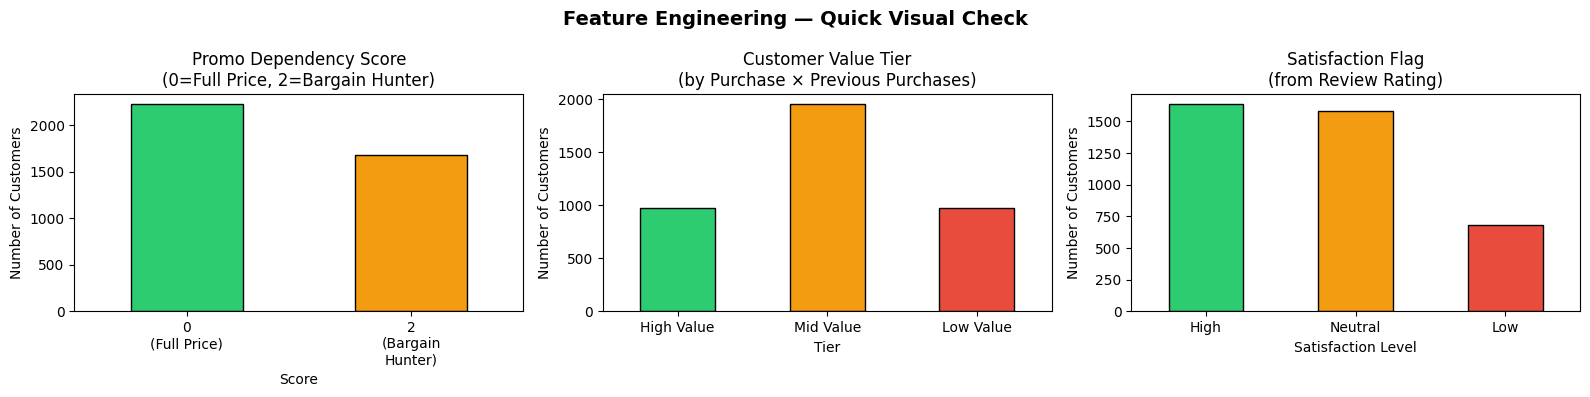

✅ Charts saved as feature_check_charts.png


In [40]:
# ────────────────────────────────────────────────────────────
# CELL 17 — QUICK VISUALISATION
# ────────────────────────────────────────────────────────────
#
# WHAT: Three simple charts to visually verify your features.
# WHY:  Seeing the data visually often reveals patterns that
#       numbers alone don't show. These are exploratory only
#

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Feature Engineering — Quick Visual Check", fontsize=14, fontweight="bold")

# Chart 1: Promo Dependency Score distribution
df["Promo_Dependency_Score"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["#2ecc71", "#f39c12", "#e74c3c"], edgecolor="black"
)
axes[0].set_title("Promo Dependency Score\n(0=Full Price, 2=Bargain Hunter)")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Number of Customers")
axes[0].set_xticklabels(["0\n(Full Price)", "2\n(Bargain\nHunter)"], rotation=0)

# Chart 2: Customer Value Tier distribution
tier_order = ["High Value", "Mid Value", "Low Value"]
tier_counts = df["Customer_Value_Tier"].value_counts().reindex(tier_order)
tier_counts.plot(
    kind="bar", ax=axes[1], color=["#2ecc71", "#f39c12", "#e74c3c"], edgecolor="black"
)
axes[1].set_title("Customer Value Tier\n(by Purchase × Previous Purchases)")
axes[1].set_xlabel("Tier")
axes[1].set_ylabel("Number of Customers")
axes[1].set_xticklabels(tier_order, rotation=0)

# Chart 3: Satisfaction Flag distribution
sat_order = ["High", "Neutral", "Low"]
sat_counts = df["Satisfaction_Flag"].value_counts().reindex(sat_order)
sat_counts.plot(
    kind="bar", ax=axes[2], color=["#2ecc71", "#f39c12", "#e74c3c"], edgecolor="black"
)
axes[2].set_title("Satisfaction Flag\n(from Review Rating)")
axes[2].set_xlabel("Satisfaction Level")
axes[2].set_ylabel("Number of Customers")
axes[2].set_xticklabels(sat_order, rotation=0)

plt.tight_layout()
plt.savefig("feature_check_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Charts saved as feature_check_charts.png")